# Predicting Stock Price Direction using SVM in Sklearn.

### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt 
import seaborn as sns

### 2. Loading Dataset

In [2]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/25-Predicting%20Stock%20Price%20Direction/RELIANCE.csv

--2026-03-17 13:45:04--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/25-Predicting%20Stock%20Price%20Direction/RELIANCE.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 246697 (241K) [text/plain]
Saving to: ‘RELIANCE.csv’

RELIANCE.csv        100%[===================>] 240.92K  1.49MB/s    in 0.2s    

2026-03-17 13:45:05 (1.49 MB/s) - ‘RELIANCE.csv’ saved [246697/246697]



In [3]:
df = pd.read_csv('RELIANCE.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0
1,2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0
2,2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0
3,2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0
4,2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0


### 3. Data Preprocessing 

1. Exploratory Data Analysis

In [4]:
df.shape

(2634, 7)

In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2634.000000,2634.000000,2634.000000,2634.000000,2634.000000,2.634000e+03
mean,593.500057,600.787471,586.714278,593.416973,556.435824,8.622828e+06
std,264.054719,266.530348,261.098518,263.770466,278.365257,5.485415e+06
min,0.000000,286.250000,266.250000,269.388000,222.757553,0.000000e+00
25%,432.568741,437.500000,426.962509,432.125000,391.739197,5.316242e+06
50%,497.174988,502.500000,491.550003,496.649994,445.431839,7.126298e+06
75%,556.181259,565.875000,546.812500,554.640991,524.052490,1.009307e+07
max,1407.949951,1417.500000,1402.650024,1408.849976,1401.091064,8.624427e+07


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2634 entries, 0 to 2633
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2634 non-null   object 
 1   Open       2634 non-null   float64
 2   High       2634 non-null   float64
 3   Low        2634 non-null   float64
 4   Close      2634 non-null   float64
 5   Adj Close  2634 non-null   float64
 6   Volume     2634 non-null   float64
dtypes: float64(6), object(1)
memory usage: 144.2+ KB


In [7]:
df.index = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2009-01-02,2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0
2009-01-05,2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0
2009-01-06,2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0
2009-01-07,2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0
2009-01-09,2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0


In [8]:
df = df.drop('Date', axis=1)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0
2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0
2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0
2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0
2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0


2. Feature Engineering

In [9]:
df['close-open'] = df['Close'] - df['Open']
df['high-low'] = df['High'] - df['Low']

In [10]:
X = df[['close-open', 'high-low']]
X.head()

,close-open,high-low
Date,,
2009-01-02,6.675018,11.975006
2009-01-05,16.712006,20.475006
2009-01-06,2.725006,14.687988
2009-01-07,-42.062012,52.750000
2009-01-09,-14.187988,29.087006


In [11]:
y = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
y

array([1, 1, 0, ..., 1, 0, 0])

3. Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4. Build and Fit the Model

In [13]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)

SVC()

### 5. Evaluate the Model

In [14]:
from sklearn.metrics import accuracy_score

training_accuracy = accuracy_score(y_train, svc.predict(X_train))
test_accuracy = accuracy_score(y_test, svc.predict(X_test))

print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Training Accuracy: 0.5268153773137162
Testing Accuracy: 0.47438330170777987


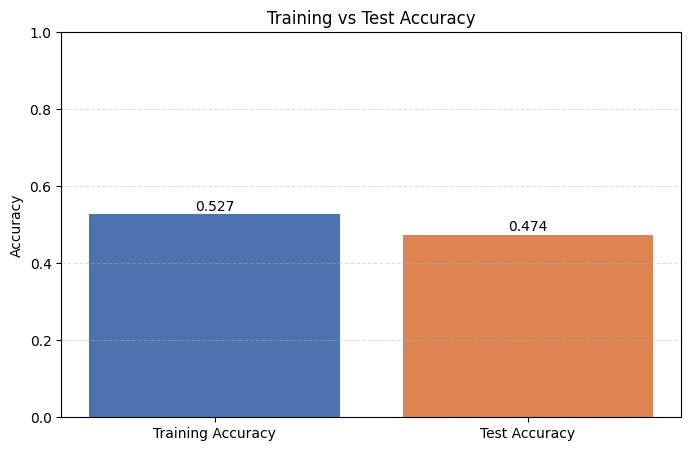

In [20]:
plt.figure(figsize=(8, 5))
labels = ['Training Accuracy', 'Test Accuracy']
accuracies = [training_accuracy, test_accuracy]
colors = ['#4C72B0', '#DD8452']

plt.bar(labels, accuracies, color=colors)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy')

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.01, f'{value:.3f}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### 6. Make Prediction


In [16]:
y_pred = svc.predict(X_test)
y_test[1], y_pred[1]

(np.int64(0), np.int64(0))